In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

In [90]:
df = sns.load_dataset('mpg')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [92]:
df_cp = df[['horsepower','mpg']]
df_cp = df_cp.dropna(subset=['horsepower', 'mpg'])
print(df_cp)

     horsepower   mpg
0         130.0  18.0
1         165.0  15.0
2         150.0  18.0
3         150.0  16.0
4         140.0  17.0
..          ...   ...
393        86.0  27.0
394        52.0  44.0
395        84.0  32.0
396        79.0  28.0
397        82.0  31.0

[392 rows x 2 columns]


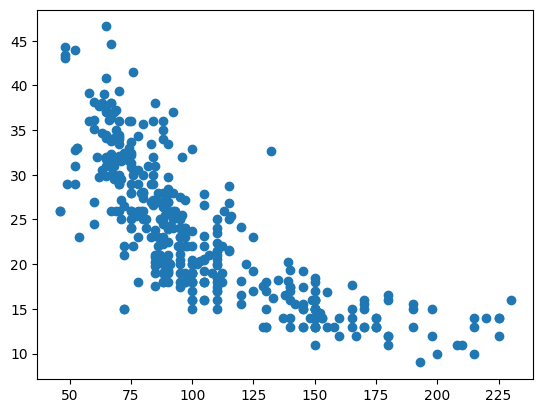

In [93]:
plt.scatter(x=df_cp['horsepower'],y=df_cp['mpg'])
plt.show()

In [94]:
from sklearn.model_selection import train_test_split

x = df_cp[['horsepower']]
y = df_cp['mpg']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [95]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [96]:
y_pred_train = model.predict(x_train)

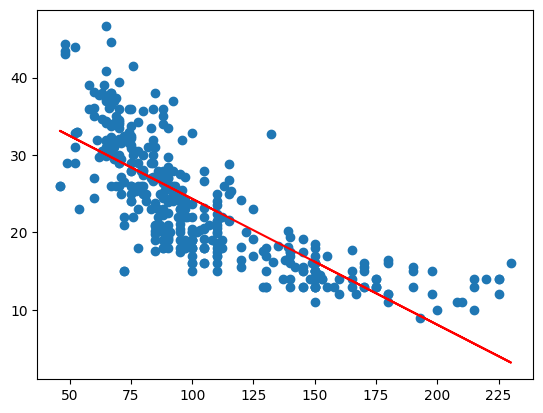

In [97]:
plt.scatter(x=df_cp['horsepower'],y=df_cp['mpg'])
plt.plot(x_train,y_pred_train,color="red")
plt.show()

In [98]:
y_pred_test = model.predict(x_test)

In [99]:
print("m =",model.coef_[0],end='')
print()
print("intercept =",model.intercept_,end='')

m = -0.16259724322918453
intercept = 40.606097600118346

In [ ]:
(y_test - y_pred_test).abs().mean()

3.782512710126959